# Dataset Analysis for Numericals Datasets

## Libraries


In [12]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [13]:
%store -r data
data=data

%store -r numerical_cols
numerical_cols=numerical_cols



##  Descriptive Analysis

#### Numerical Data

In [14]:
numerical_cols= data.select_dtypes(include=['int64','float64' ]).columns.tolist()
print(data[numerical_cols].columns)
print(data[numerical_cols])

Index(['Year of manufacture', 'Mileage', 'Engine power (hp)',
       'Energy consumption', 'Number of doors', 'Number of seats',
       'Number of previous owners', 'Dealer rating', 'Price (EUR)'],
      dtype='object')
    Year of manufacture  Mileage  Engine power (hp)  Energy consumption  \
55                 2009   110639                199                15.7   
88                 2015    77371                 75                 8.1   
26                 2015    94588                 60                 7.8   
42                 2014    40473                116                 5.5   
69                 2005   115689                180                 5.4   
..                  ...      ...                ...                 ...   
60                 2023   121283                 98                15.1   
71                 2015   122569                131                 6.4   
14                 2019    84217                131                 5.3   
92                 2006    999

In [15]:
def kde_plot(x):
    col = x[0]

    plt.figure(figsize=(12,6))

    # Histogramm
    sns.histplot(data[x[0]], kde=False, alpha=0.25)

    # KDE-Plot
    sns.kdeplot(data[x[0]], linewidth=5)
    
    # Calculate mean and median
    mean=data[col].mean()
    median=data[col].median()
    
    # Add mean and median lines
    plt.axvline(mean, color='r', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='-', label=f'Median: {median:.2f}')
    
    # Add legend and labels
    plt.legend()
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(x)
    plt.ylabel('Density')

    return plt.show()



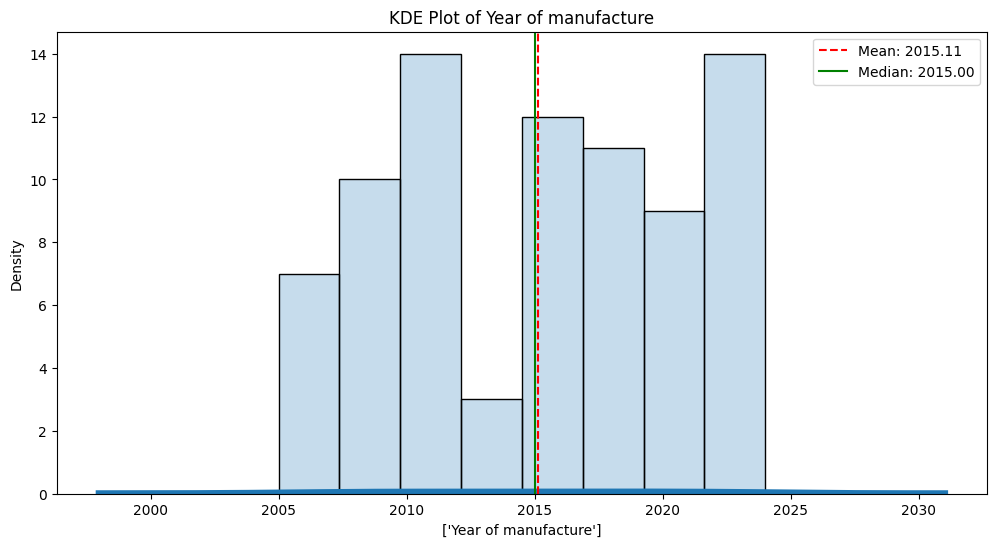

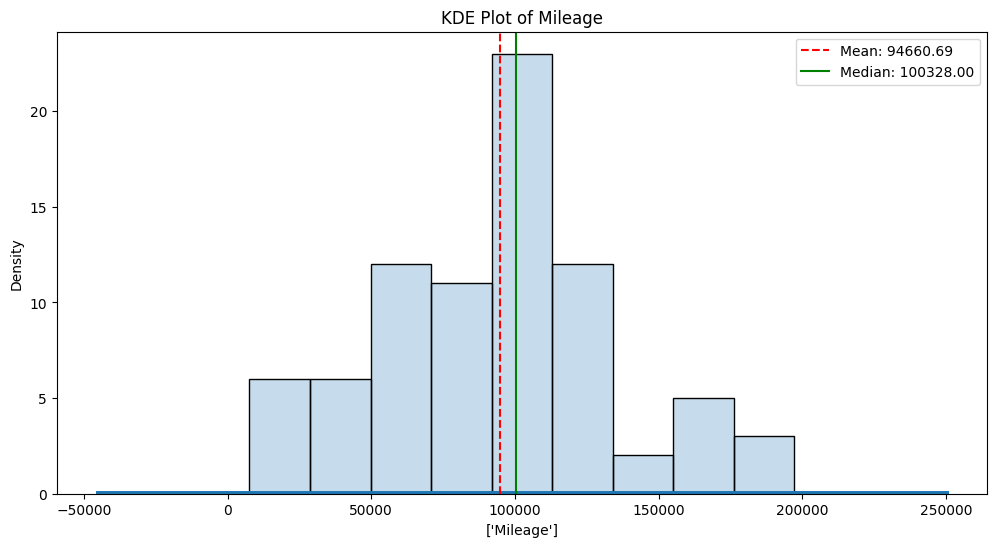

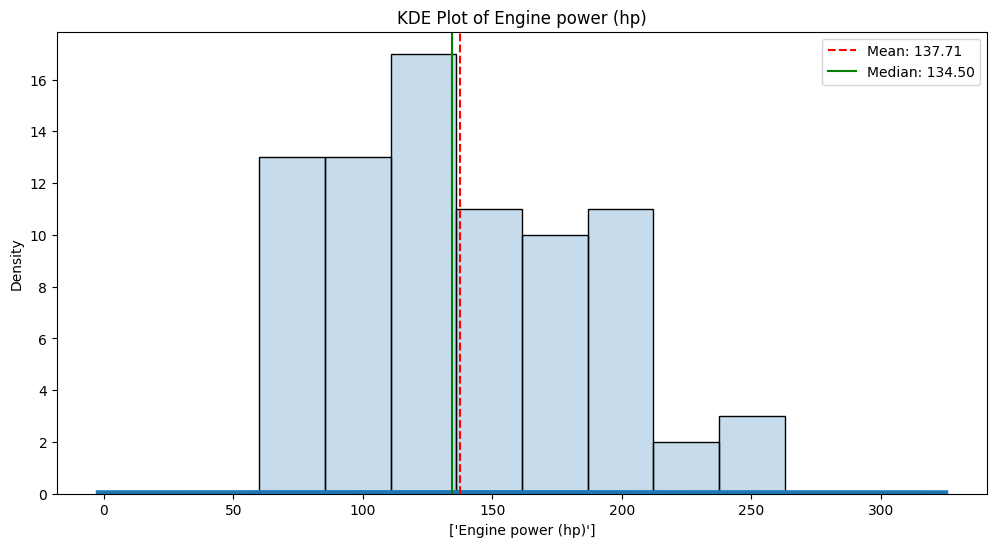

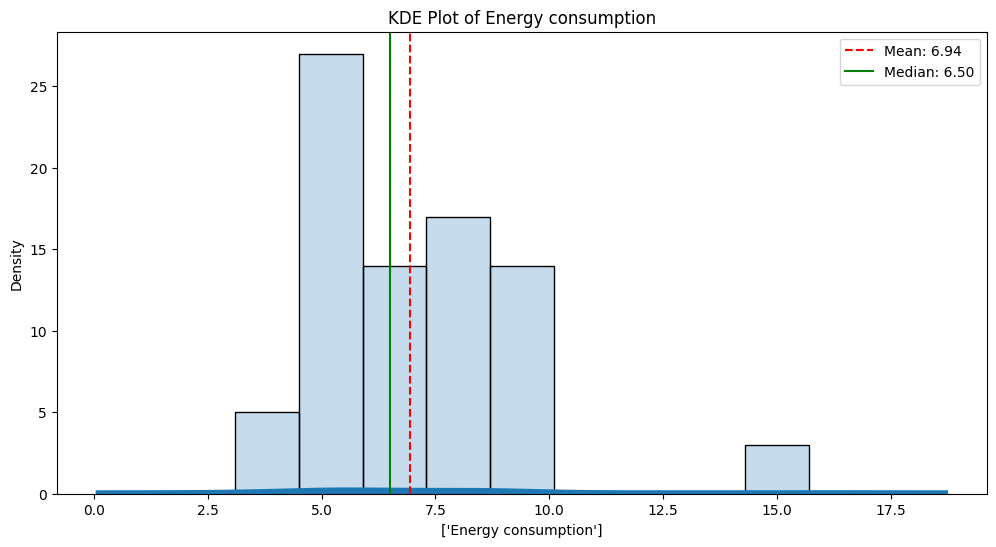

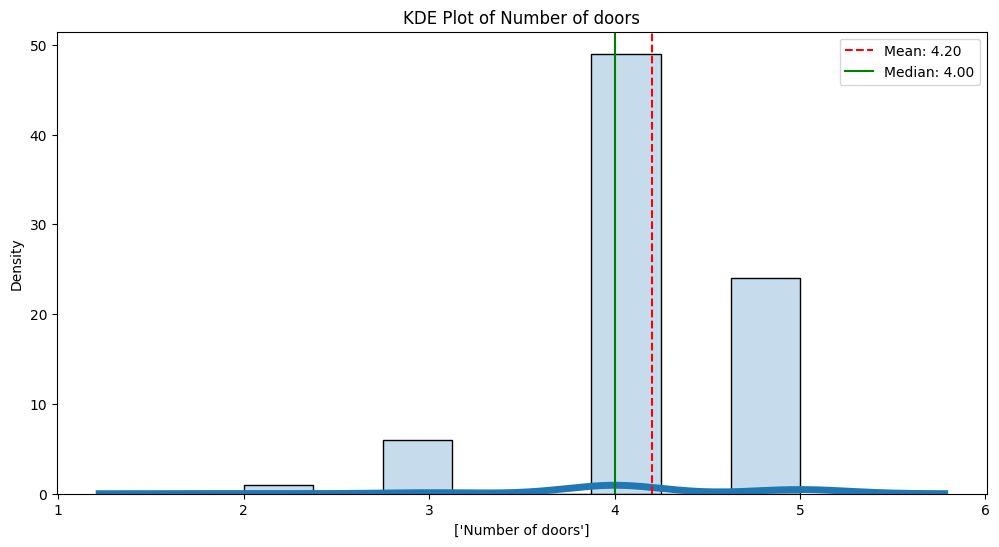

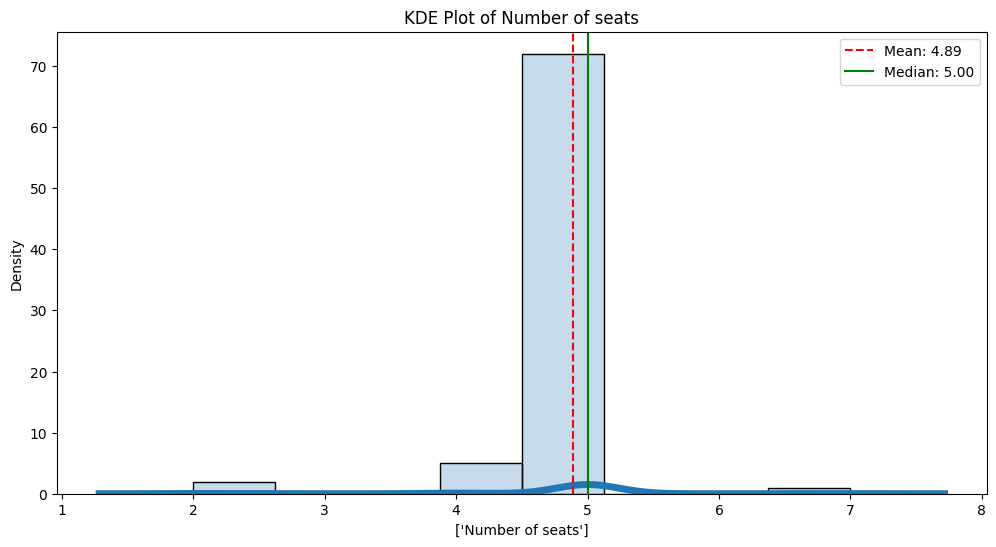

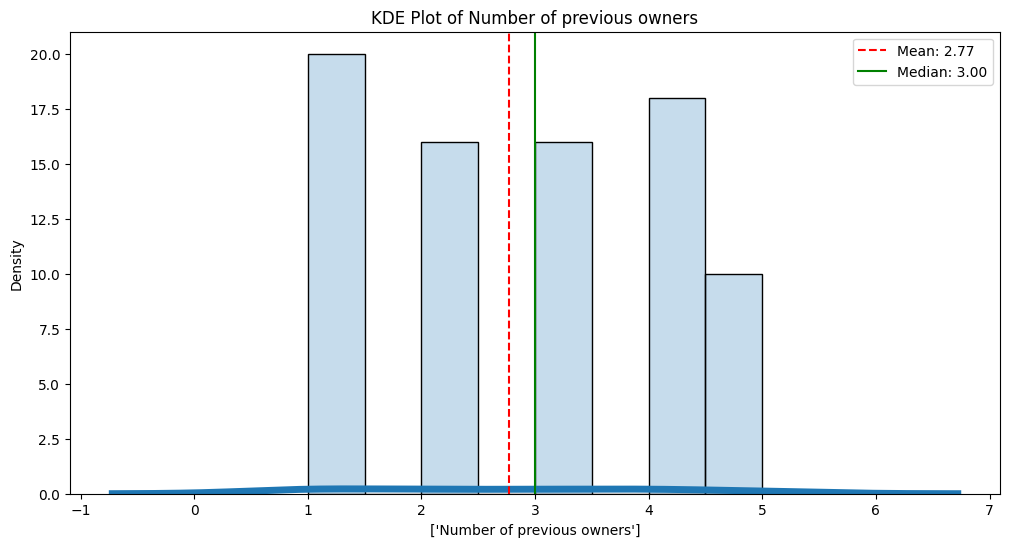

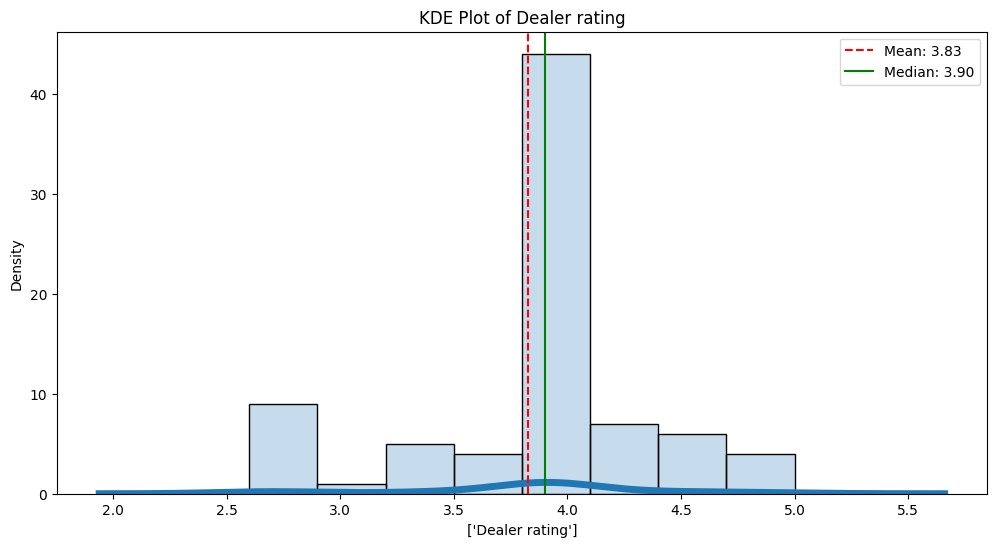

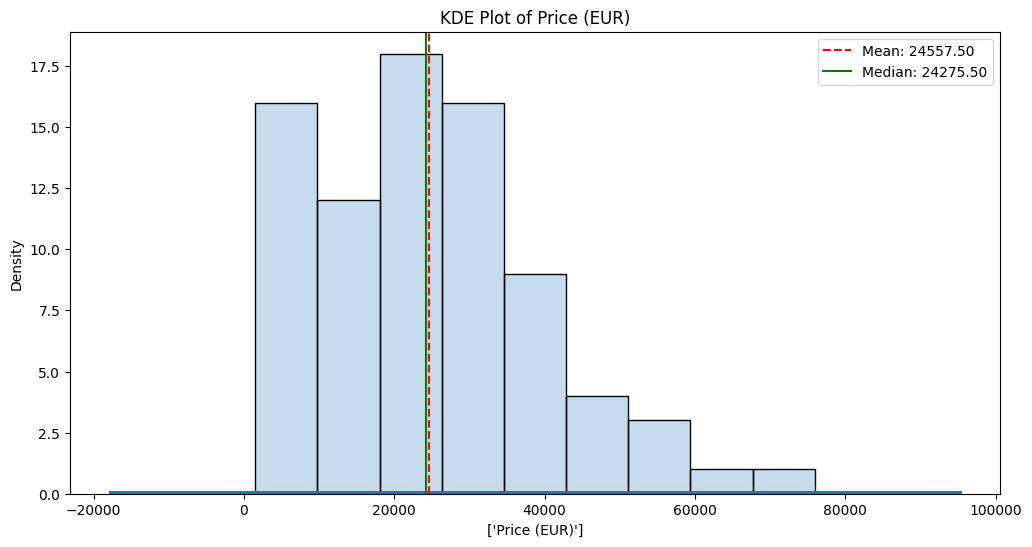

In [16]:
# Generate KDE plots for all numerical columns
for col in numerical_cols:
    kde_plot([col])

    print('\n\n')

#### Scatter Plot

In [17]:
def scatter_plot(x):
    col=x[0]

    plt.figure(figsize=(12,6))

    # Scatter plot with regression line 
    sns.scatterplot(x=data[col], y=data['Price (EUR)'], alpha=0.5, color='red')
    sns.regplot(x=data[col], y=data['Price (EUR)'], scatter=False, color='black', line_kws={"linewidth":3})
    # Add labels and title 
    plt.title(f'Scatter Plot of {col} vs Price (EUR)')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')

    return plt.show()

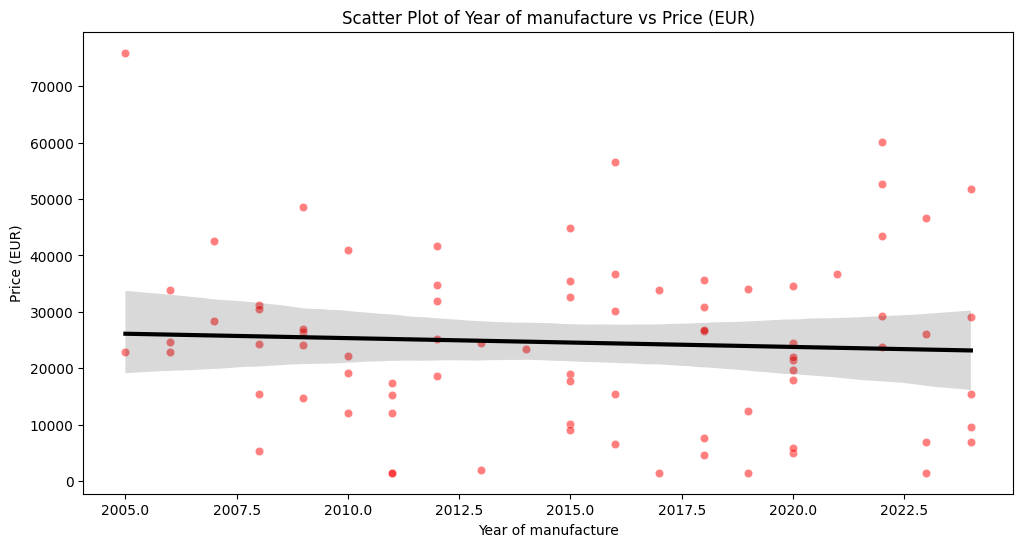

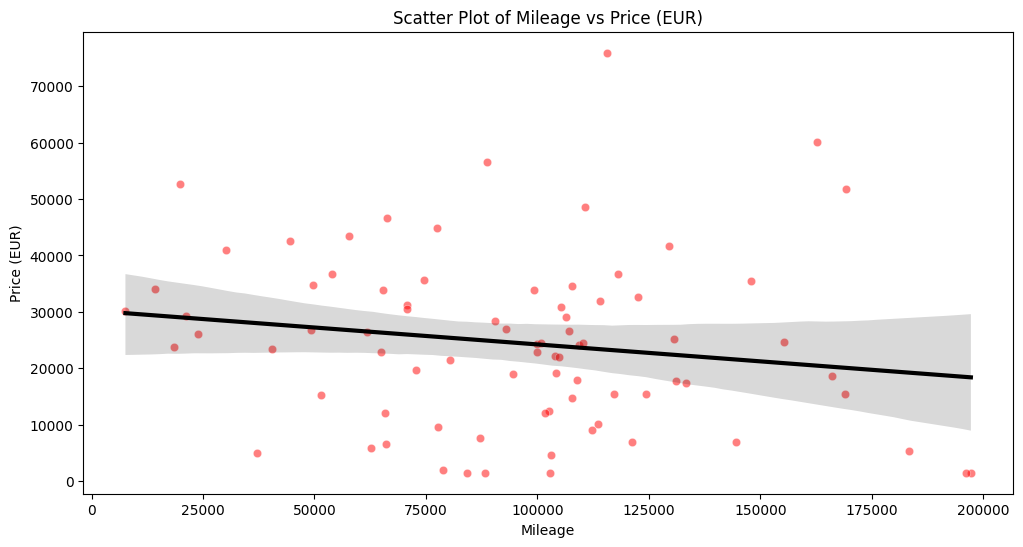

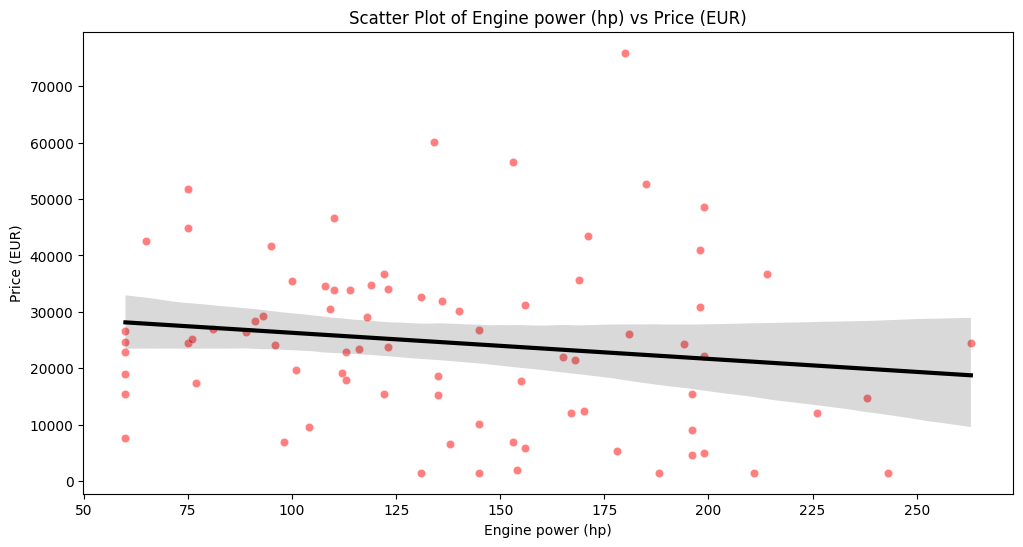

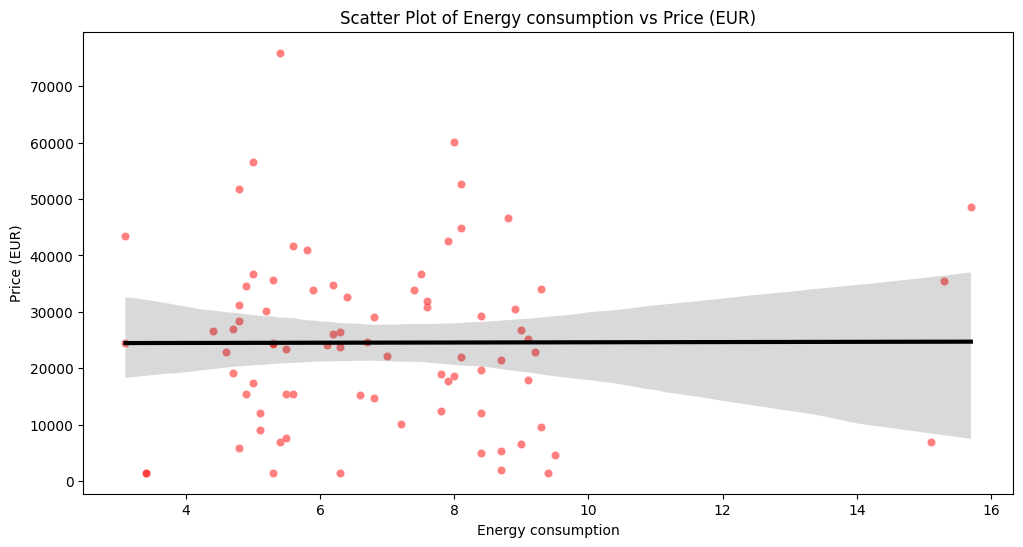

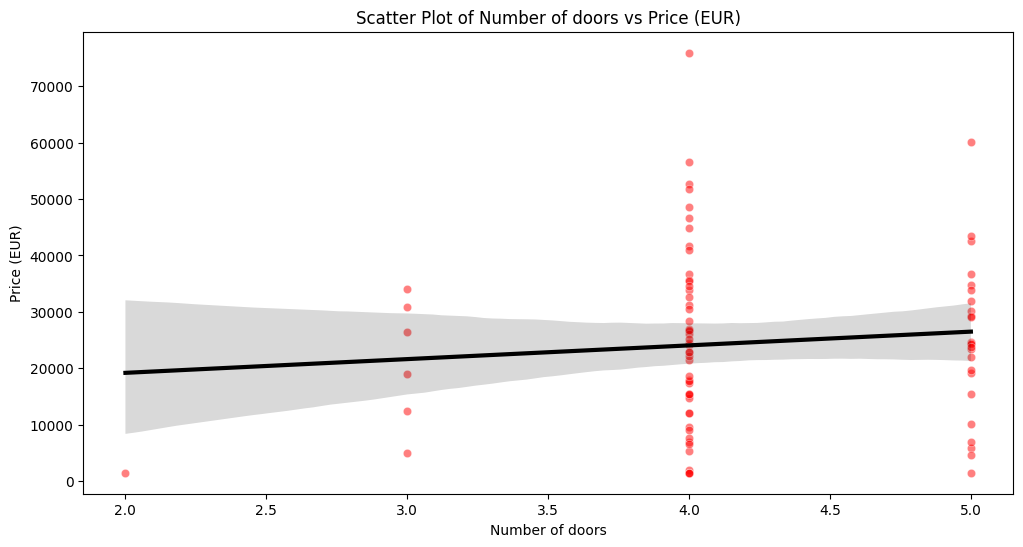

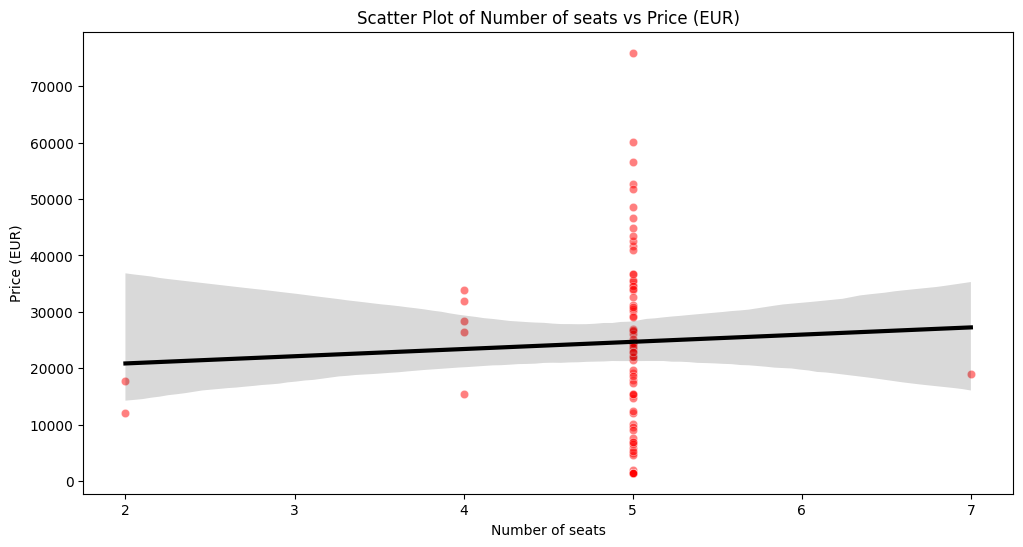

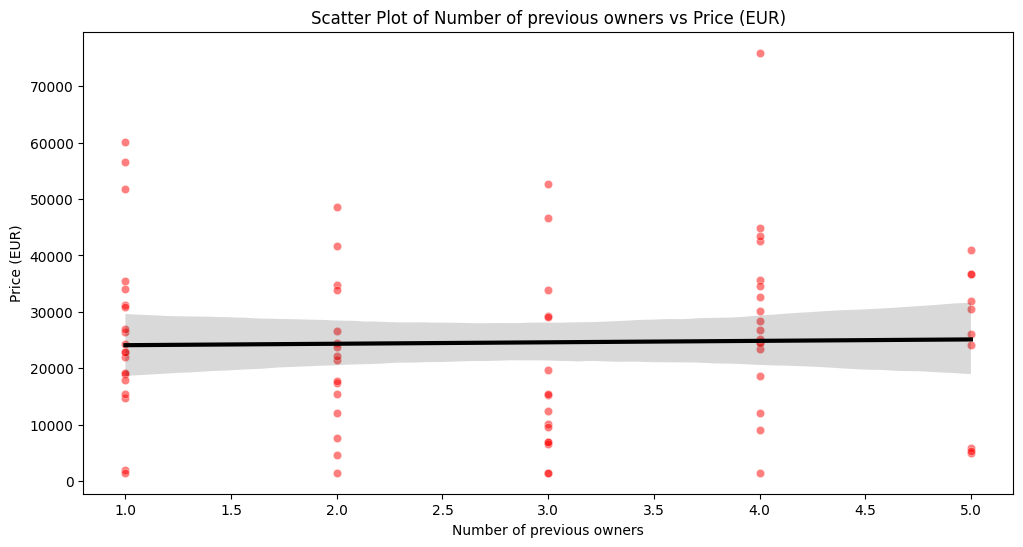

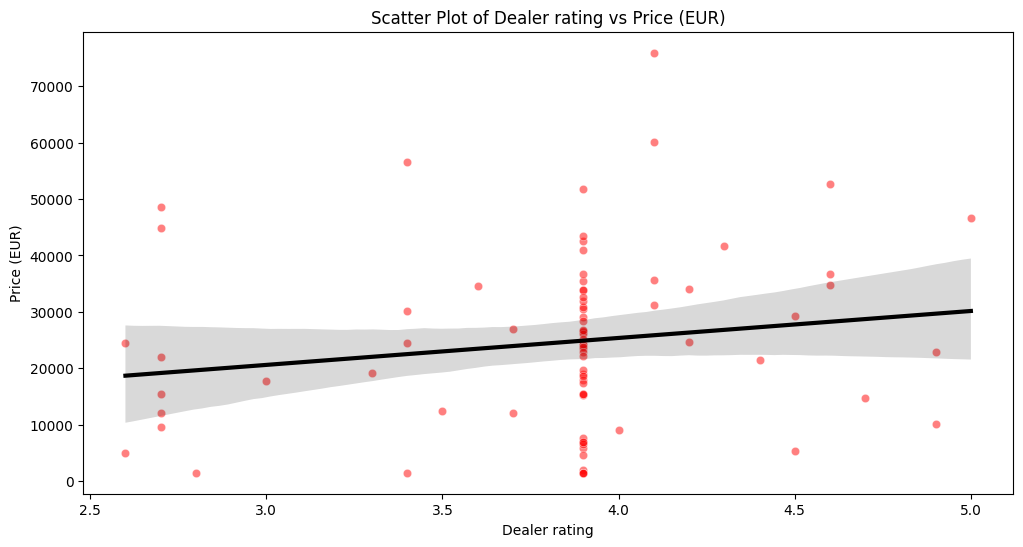

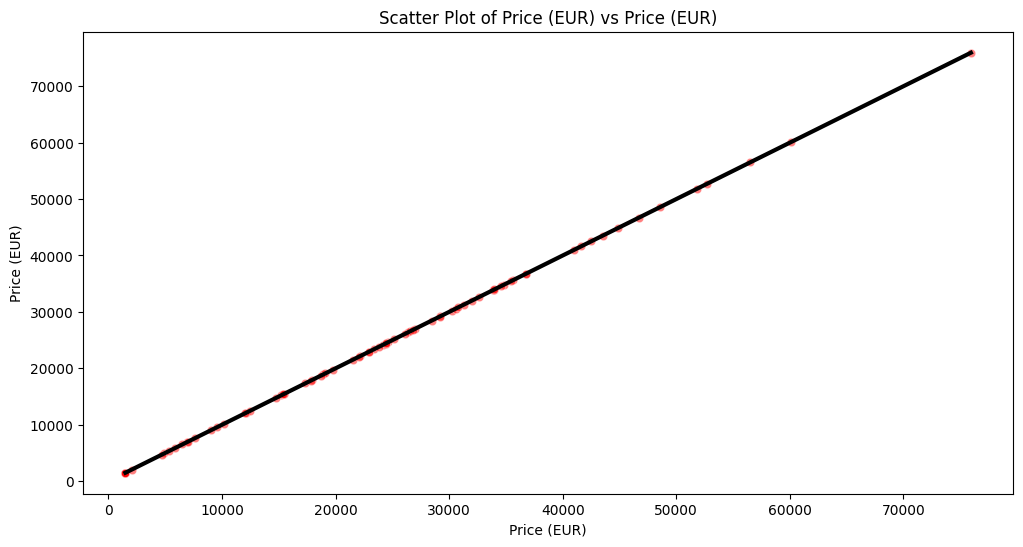

In [18]:
for col in numerical_cols:
    scatter_plot([col])

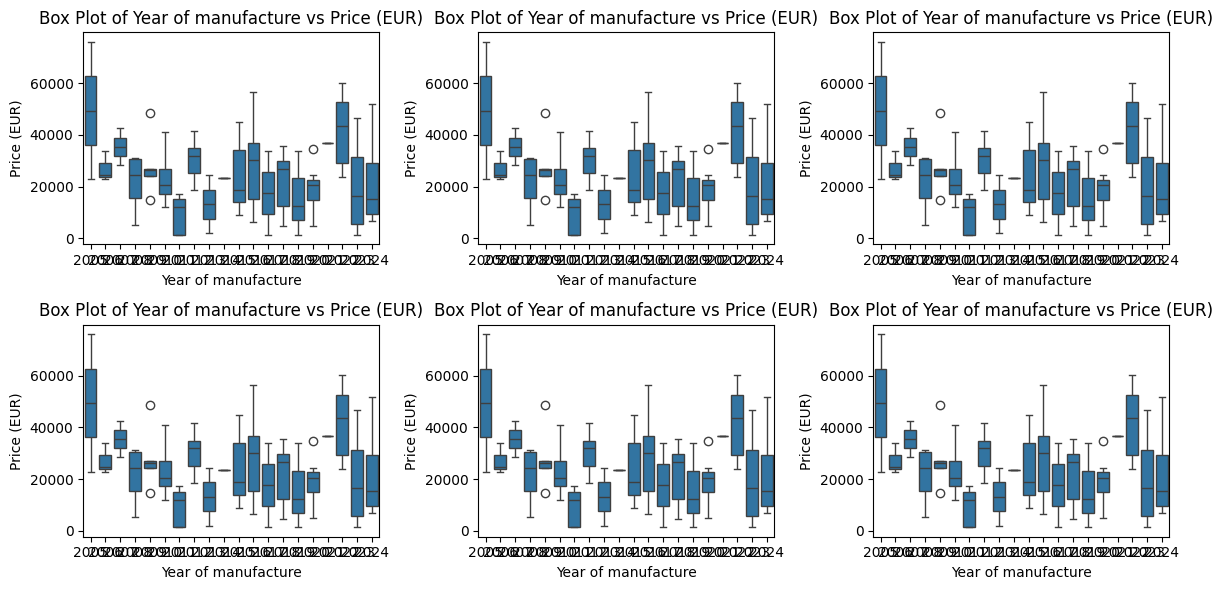

In [19]:
def box_plot(x):
    col=x[0]
    
    fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(12,6))

    for i, ax in enumerate(axes.flatten()):
        sns.boxplot(x=data[col], y=data['Price (EUR)'], ax=ax)
        ax.set_title(f'Box Plot of {col} vs Price (EUR)')
        ax.set_xlabel(col)
        ax.set_ylabel('Price (EUR)')

    plt.tight_layout()
    return plt.show()
        
box_plot(numerical_cols)


#### Correlation Variables
Analyse relation between variables.

Domain: -1 to 1

. 1 -> perfect positive correlation
. -1 -> perfect negative correlation
. 0 -> no correlation


| r (Korrelationskoeffizient) | Stärke des Zusammenhangs |
| --------------------------- | ------------------------ |
| 0.00 – 0.19                 | sehr schwach             |
| 0.20 – 0.39                 | schwach                  |
| 0.40 – 0.59                 | mittel                   |
| 0.60 – 0.79                 | stark                    |
| 0.80 – 1.0                  | sehr stark               |


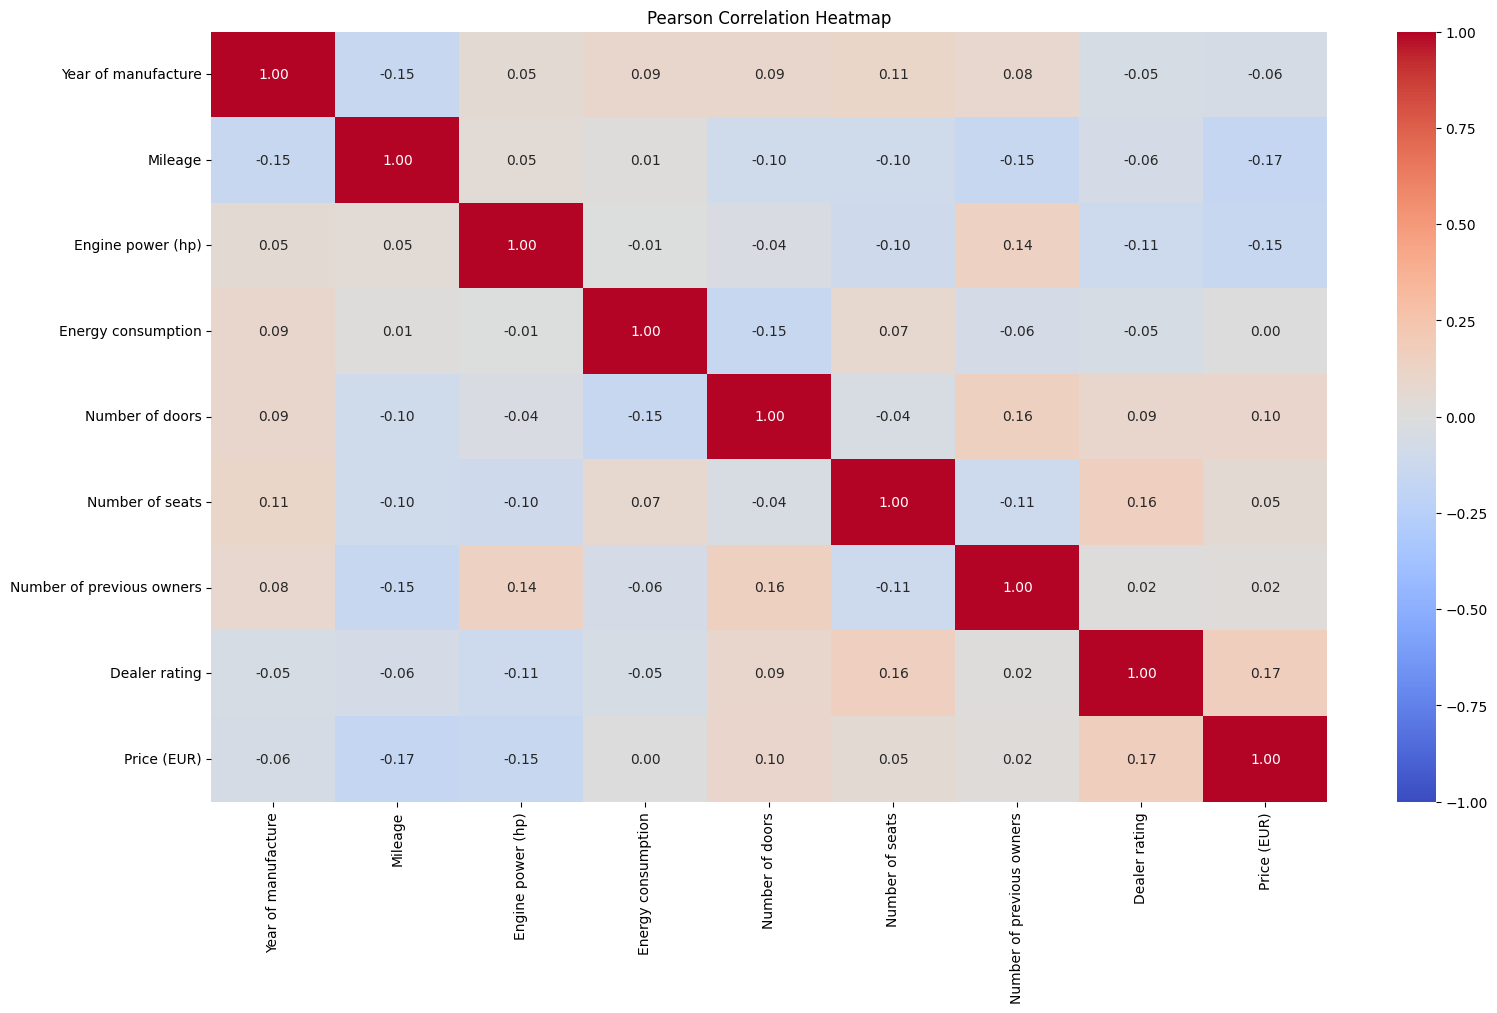

In [20]:
pearson_corr = data[numerical_cols].corr(method='pearson')
plt.figure(figsize=(18, 10))
sns.heatmap(pearson_corr,
             annot=True,
             vmax=1,
             vmin=-1,
             fmt=".2f", 
             cmap='coolwarm', 
             center=0)
plt.title('Pearson Correlation Heatmap')
plt.show()